# Step 4 — Baseline Models (Random Forest + Climatology + Persistence)

**Project:** VNKT Winter Fog Forecasting (STW7085CEM Task 1)

Thin wrapper around `scripts/baseline_models.py`. All training and metrics code lives in the script; this notebook orchestrates and renders the six figures.

**What this step does**

1. Trains four predictors on every CV fold:
   - `RandomForestRegressor` for `target_min_vis_m`
   - `RandomForestClassifier` for `target_class` (3-way, `class_weight='balanced'`)
   - Climatology baseline (per-day-of-year mean from training data only)
   - Persistence baseline (tomorrow = tonight's sunset visibility)
2. Writes `data/processed/rf_oof_predictions.parquet` (1206 rows: all 8 test folds concatenated)
3. Writes `data/processed/step4_metrics.json` (per-fold + aggregate metrics)
4. Produces six figures into `reports/figures/`:
   - Per-fold regression metrics (RF vs climatology vs persistence)
   - Predicted vs actual scatter with 90% predictive intervals
   - Per-fold classification metrics
   - Aggregate confusion matrix
   - Feature importance (Gini + permutation)
   - Reliability diagrams — the paper's headline calibration figure

**Headline result for the paper** (anticipated, generated below):

- RF MAE ≈ 830m, R² ≈ 0.63 on out-of-fold winter visibility
- RF 90% predictive interval covers only ≈ 80% of true values — **over-confident**
- RF correctly classifies only ≈ 8% of Diversions days — the rare-class failure
  that motivates the GP calibration story in Steps 5–6

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'scripts'))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from baseline_models import (
    RF_REG_PARAMS, RF_CLF_PARAMS,
    train_and_evaluate, aggregate_metrics,
    DEFAULT_OOF_PATH, DEFAULT_METRICS_PATH,
)
from cv_splits import load_modelling_table, split_holdout, FEATURE_COLUMNS
from step4_plots import (
    plot_regression_metrics, plot_predicted_vs_actual,
    plot_classification_metrics, plot_confusion_matrix,
    plot_feature_importance, plot_reliability_diagram,
)

print(f'Project root: {PROJECT_ROOT}')
print(f'RF regressor params:  {RF_REG_PARAMS}')
print(f'RF classifier params: {RF_CLF_PARAMS}')

Project root: /home/saggy/Desktop/advanced-ml-assignement
RF regressor params:  {'n_estimators': 500, 'min_samples_leaf': 2, 'random_state': 42, 'n_jobs': -1}
RF classifier params: {'n_estimators': 500, 'min_samples_leaf': 2, 'random_state': 42, 'n_jobs': -1, 'class_weight': 'balanced'}


## 1. Train models on every CV fold

Runs the full training loop end to end. On a Ryzen 7 CPU this takes roughly 60–90 seconds (eight folds × two RF models × 500 trees × permutation importance).

In [2]:
df = load_modelling_table()
train_pool, holdout = split_holdout(df)

results, oof = train_and_evaluate(train_pool, n_perm_repeats=10)
metrics = aggregate_metrics(results, oof)

# Persist for the downstream calibration step
oof.to_parquet(DEFAULT_OOF_PATH, index=False)
DEFAULT_METRICS_PATH.write_text(json.dumps(metrics, indent=2))
print(f'Wrote {DEFAULT_OOF_PATH}  ({len(oof)} rows)')
print(f'Wrote {DEFAULT_METRICS_PATH}')

[22:21:13] INFO  Loading modelling table: /home/saggy/Desktop/advanced-ml-assignement/data/processed/vnkt_modelling_table.parquet
[22:21:13] INFO    rows=1561  seasons=11  date_range=2016-01-02 -> 2026-02-28
[22:21:13] INFO  Holdout season 2025-26: 151 rows  |  train pool: 1410 rows across 10 seasons
[22:21:13] INFO  Built 8 forward-chaining folds
[22:21:13] INFO  Fold 1 (2017-18): train n=204, test n=151
[22:21:22] INFO  Fold 2 (2018-19): train n=355, test n=149
[22:21:27] INFO  Fold 3 (2019-20): train n=504, test n=152
[22:21:32] INFO  Fold 4 (2020-21): train n=656, test n=150
[22:21:38] INFO  Fold 5 (2021-22): train n=806, test n=150
[22:21:43] INFO  Fold 6 (2022-23): train n=956, test n=151
[22:21:49] INFO  Fold 7 (2023-24): train n=1107, test n=152
[22:21:55] INFO  Fold 8 (2024-25): train n=1259, test n=151


Wrote /home/saggy/Desktop/advanced-ml-assignement/data/processed/rf_oof_predictions.parquet  (1206 rows)
Wrote /home/saggy/Desktop/advanced-ml-assignement/data/processed/step4_metrics.json


## 2. Headline aggregate metrics

Computed on the concatenated out-of-fold predictions (1206 nights = 8 test folds). These are the numbers the paper will cite.

In [3]:
agg = metrics['aggregate']

reg_rows = []
for name, key in [('Random Forest', 'rf_regression'),
                  ('Climatology',   'climatology_regression'),
                  ('Persistence',   'persistence_regression')]:
    m = agg[key]
    reg_rows.append({
        'Model': name,
        'MAE (m)': round(m['mae_m'], 0),
        'RMSE (m)': round(m['rmse_m'], 0),
        'R²': round(m['r2'], 3),
        '90% PI coverage': round(m['pi90_coverage'], 3) if m.get('pi90_coverage') is not None else None,
        '90% PI width (m)': round(m['pi90_mean_width_m'], 0) if m.get('pi90_mean_width_m') is not None else None,
    })
reg_df = pd.DataFrame(reg_rows).set_index('Model')
print('Regression headline (out-of-fold aggregate)')
reg_df

Regression headline (out-of-fold aggregate)


,MAE (m),RMSE (m),R²,90% PI coverage,90% PI width (m)
Model,,,,,
Random Forest,832.0,1100.0,0.629,0.802,2774.0
Climatology,1135.0,1477.0,0.330,NaN,NaN
Persistence,3792.0,4123.0,-4.218,NaN,NaN


In [4]:
clf = agg['rf_classification']
clf_rows = [
    {'Metric': 'Accuracy', 'Value': round(clf['accuracy'], 3)},
    {'Metric': 'Balanced accuracy', 'Value': round(clf['balanced_accuracy'], 3)},
    {'Metric': 'Macro F1', 'Value': round(clf['macro_f1'], 3)},
    {'Metric': 'Multi-class Brier', 'Value': round(clf['multiclass_brier'], 3)},
    {'Metric': 'F1 (Normal)', 'Value': round(clf['per_class_f1']['Normal'], 3)},
    {'Metric': 'F1 (Delays)', 'Value': round(clf['per_class_f1']['Delays'], 3)},
    {'Metric': 'F1 (Diversions)', 'Value': round(clf['per_class_f1']['Diversions'], 3)},
    {'Metric': 'Precision (Diversions)', 'Value': round(clf['per_class_precision']['Diversions'], 3)},
    {'Metric': 'Recall (Diversions)', 'Value': round(clf['per_class_recall']['Diversions'], 3)},
]
print('RF classification headline (out-of-fold aggregate, 3-way)')
pd.DataFrame(clf_rows).set_index('Metric')

RF classification headline (out-of-fold aggregate, 3-way)


,Value
Metric,
Accuracy,0.789
Balanced accuracy,0.570
Macro F1,0.534
Multi-class Brier,0.280
F1 (Normal),0.864
F1 (Delays),0.642
F1 (Diversions),0.095
Precision (Diversions),0.118
Recall (Diversions),0.080


## 3. Figures

All six figures are saved to `reports/figures/` and displayed inline below.

Wrote /home/saggy/Desktop/advanced-ml-assignement/reports/figures/step4_regression_metrics.png


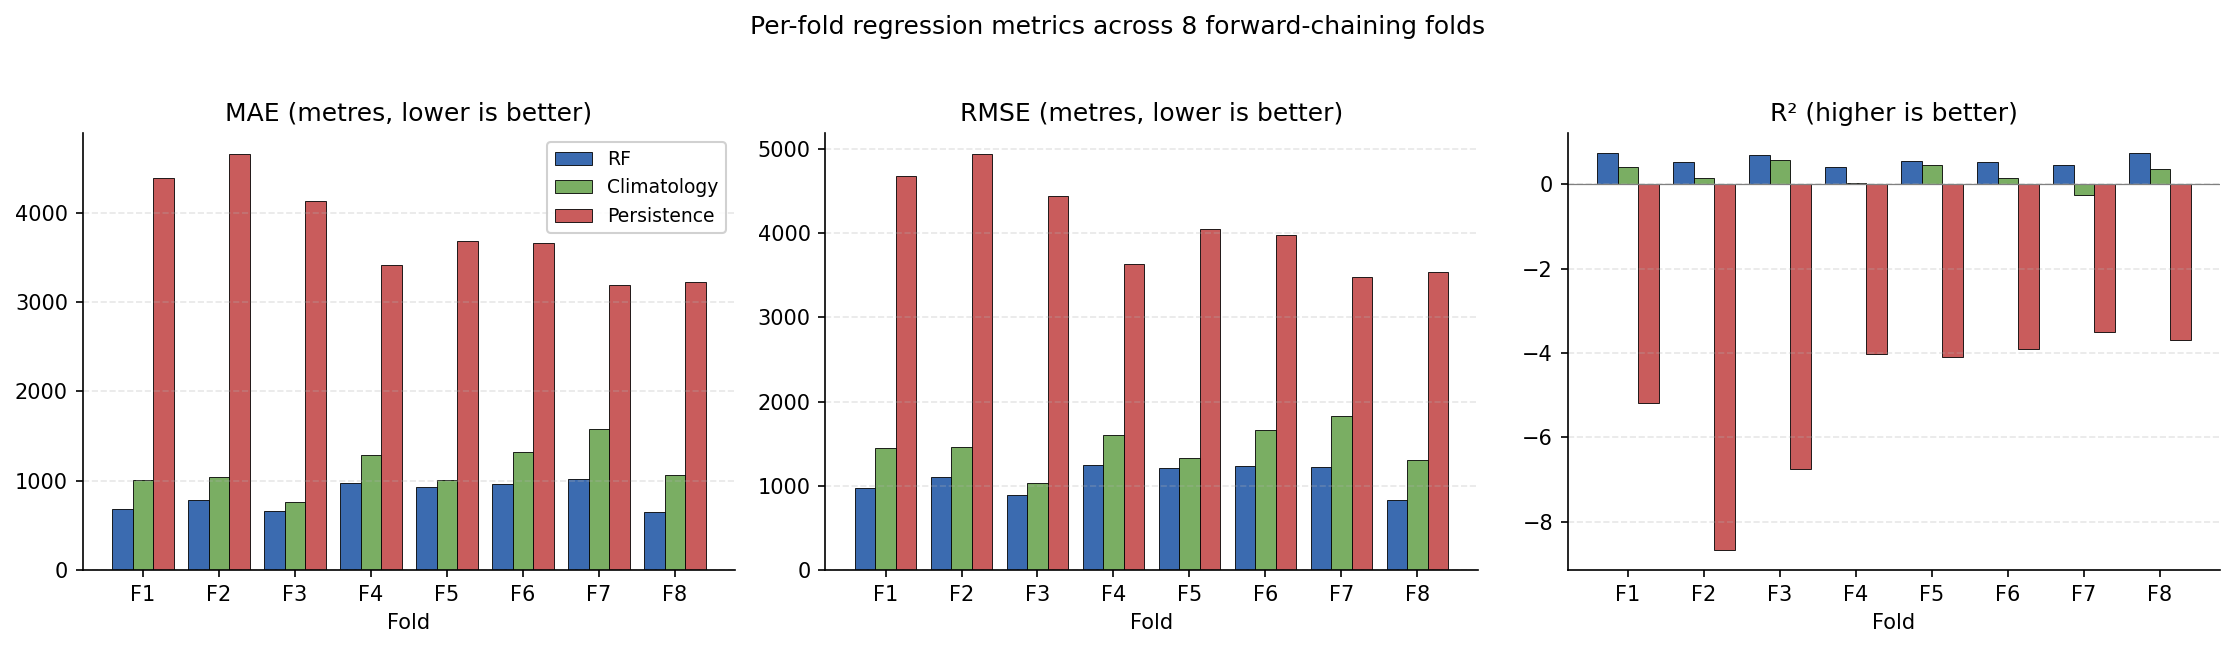

In [5]:
p = plot_regression_metrics(metrics)
print(f'Wrote {p}')
display(Image(filename=str(p)))

Wrote /home/saggy/Desktop/advanced-ml-assignement/reports/figures/step4_predicted_vs_actual.png


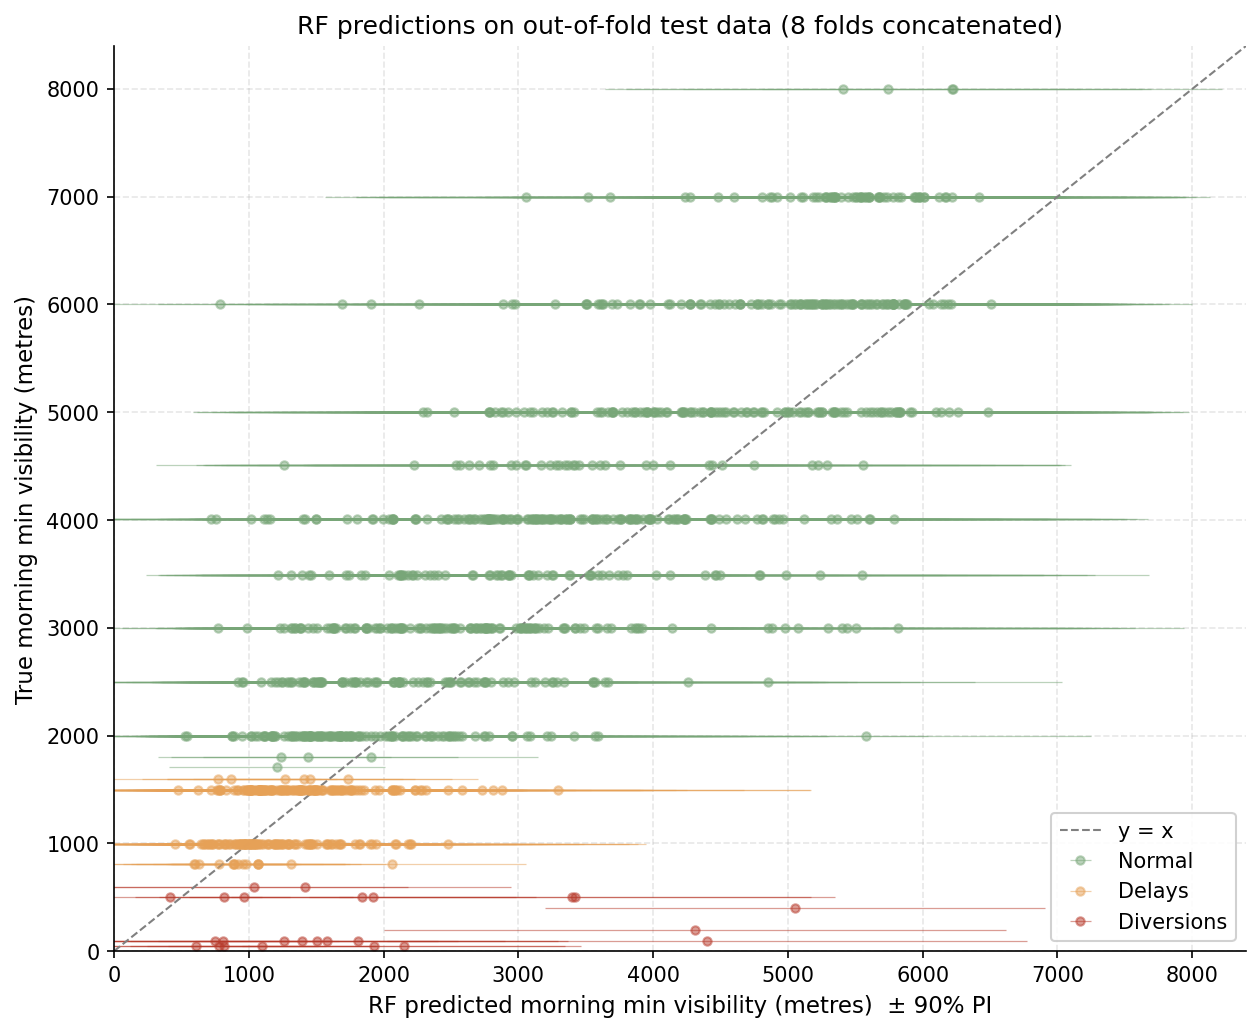

In [6]:
p = plot_predicted_vs_actual(oof)
print(f'Wrote {p}')
display(Image(filename=str(p)))

Wrote /home/saggy/Desktop/advanced-ml-assignement/reports/figures/step4_classification_metrics.png


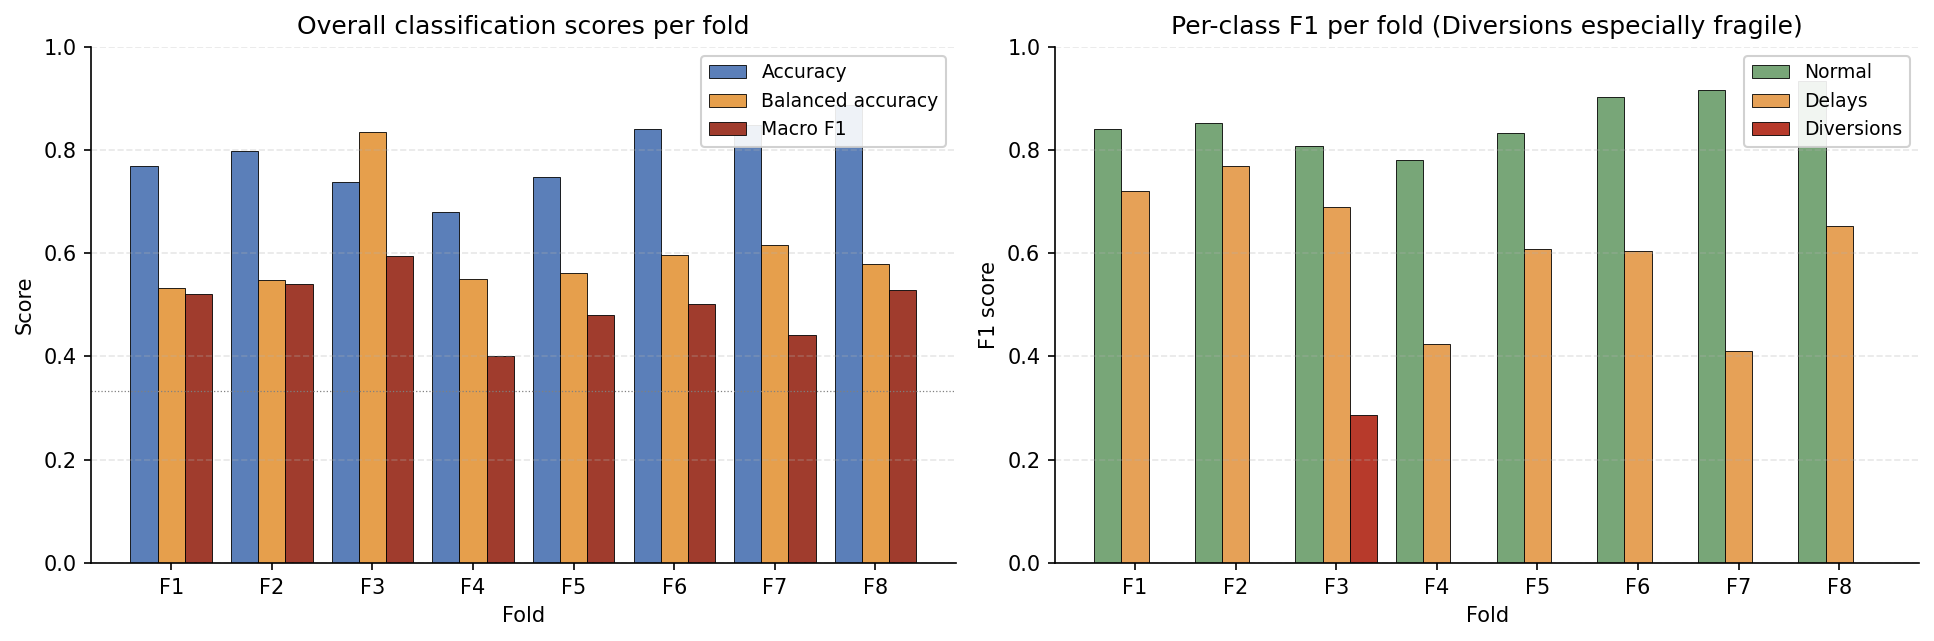

In [7]:
p = plot_classification_metrics(metrics)
print(f'Wrote {p}')
display(Image(filename=str(p)))

Wrote /home/saggy/Desktop/advanced-ml-assignement/reports/figures/step4_confusion_matrix.png


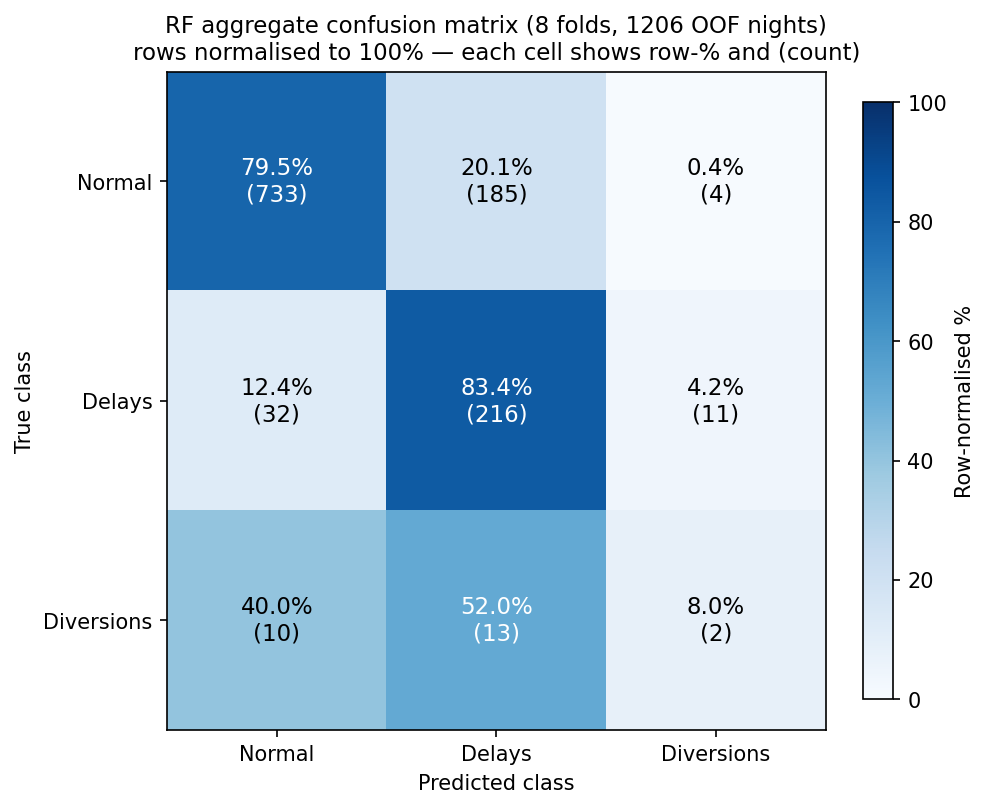

In [8]:
p = plot_confusion_matrix(metrics)
print(f'Wrote {p}')
display(Image(filename=str(p)))

Wrote /home/saggy/Desktop/advanced-ml-assignement/reports/figures/step4_feature_importance.png


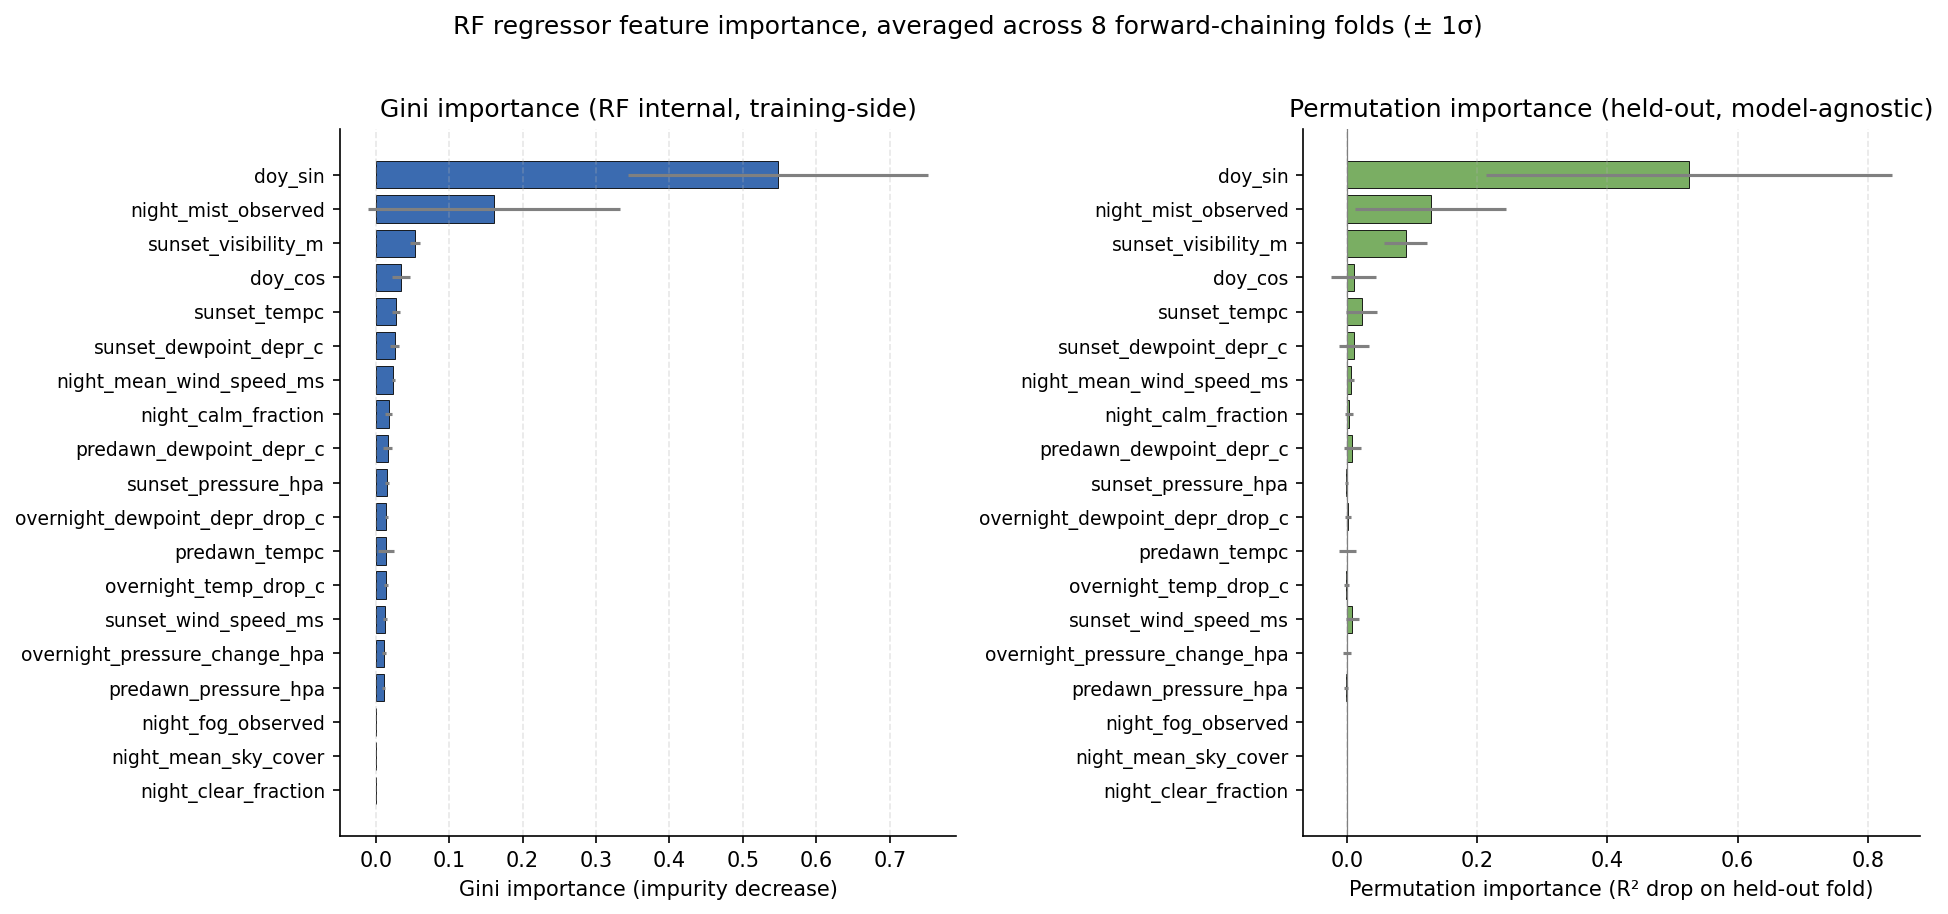

In [9]:
p = plot_feature_importance(metrics)
print(f'Wrote {p}')
display(Image(filename=str(p)))

Wrote /home/saggy/Desktop/advanced-ml-assignement/reports/figures/step4_reliability_diagram.png


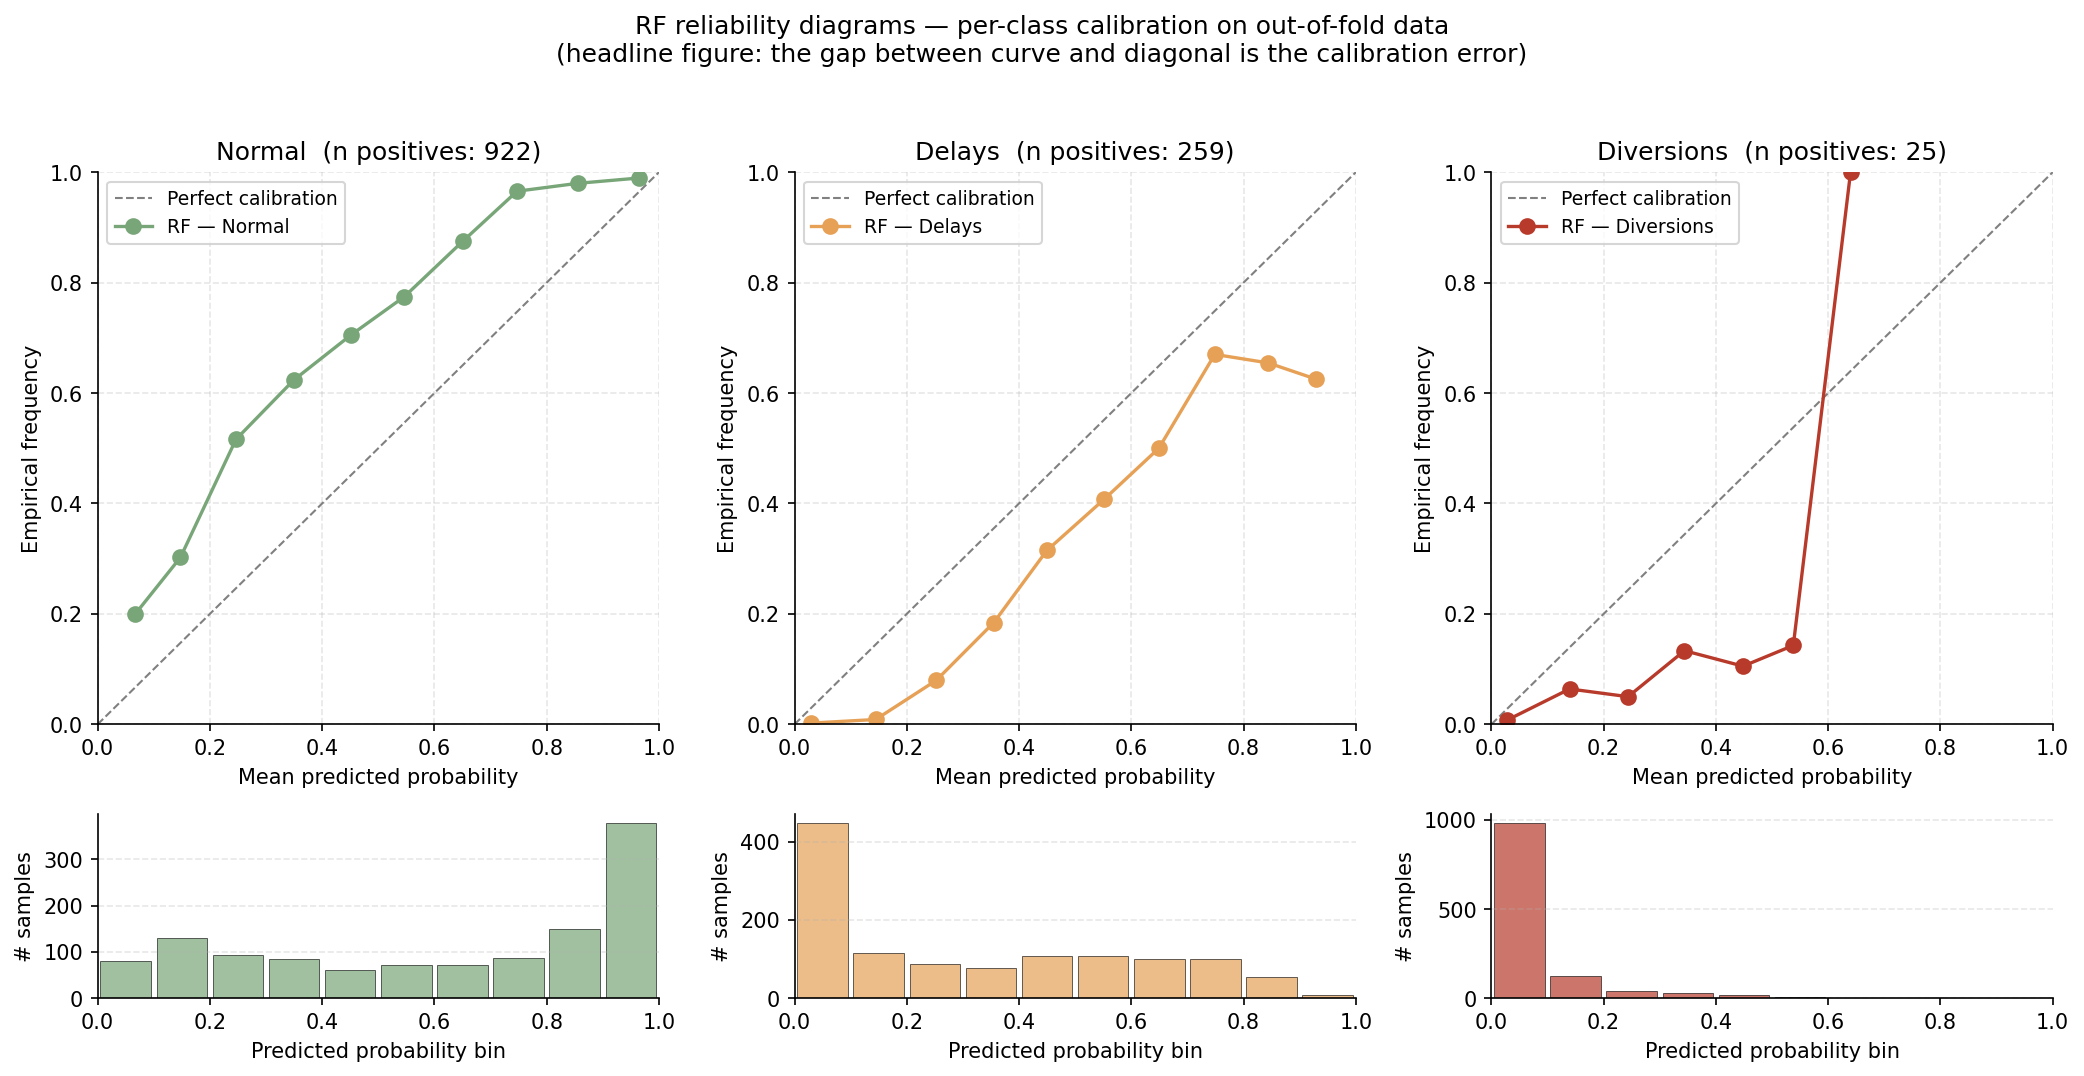

In [10]:
p = plot_reliability_diagram(oof)
print(f'Wrote {p}')
display(Image(filename=str(p)))

## 4. Read of the results, ahead of Step 5

**Regression**
- RF beats climatology, climatology beats persistence — clean monotone ordering of model sophistication vs accuracy. RF R² ≈ 0.63 is a strong baseline for a weather-forecasting task with a hard rare-event tail.
- The 90% predictive interval achieves only ≈ 80% empirical coverage. RF is **over-confident**: its intervals are too narrow. This is precisely the failure mode a properly calibrated GP regressor should beat in Step 5.

**Classification**
- Diversions F1 ≈ 0.10 — RF cannot reliably identify the operationally critical rare class even with `class_weight='balanced'`. Only 2 of ≈ 25 Diversions days are correctly labelled.
- The reliability diagram makes the under-confidence-on-Normal and over-confidence-on-Delays patterns visible. Diversions probabilities are almost all in the [0, 0.1] bin — the model rarely commits to a high Diversions probability.
- Multi-class Brier ≈ 0.28. This is the number GP-RobustMax must beat in Step 6.

**Feature importance**
- `doy_sin` dominates by a wide margin: winter seasonality (deep-Dec / mid-Jan cluster) is the strongest signal in the data.
- `night_mist_observed` and `sunset_visibility_m` follow. These three together account for most of the predictive signal — thermodynamic features (overnight temperature drop, dewpoint depression) play a supporting role only.
- `night_clear_fraction` and `night_fog_observed` have near-zero importance, consistent with the Step 3 finding that these features are sparse / constant in early folds.

**Ready for Step 5:** GPflow Matérn-5/2 + ARD regression, with the same `iter_prepared_folds(train_pool)` interface and the same six-figure layout for direct apples-to-apples comparison.